# Mazabuka Municipal Council — Data Collection, Extraction & Cleaning Pipeline

**CSC 4792: Data Mining and Warehousing — Mini Project (Group 16)**

**Assigned council:** Mazabuka Municipal Council (Project Team #16)
**Official source:** https://www.mazabukacouncil.gov.zm (catalogued by the Ministry of Local
Government and Rural Development, https://www.mlgrd.gov.zm)

This notebook documents, end-to-end, how the `db-unza26-csc4792-*.csv` datasets in `dataset/`
were built: crawling the council website, downloading every linked document, extracting
structured data from PDFs (both born-digital and scanned/OCR'd), cataloguing the remaining
administrative/report documents, and cleaning everything into the final pipe (`|`) separated
CSV files.

The reusable extraction code lives in `src/` as plain Python modules; this notebook imports
and runs them, and narrates every decision, so the whole pipeline is reproducible from a
clean checkout (`pip install -r requirements.txt`, then run the cells top to bottom).

**Data points targeted** (per the assignment brief):
- Constituency Development Fund (CDF): allocations, project approvals, beneficiary lists
- Approved budgets, revenue streams (market fees, local taxes, levies), LGEF utilisation
- Integrated Development Plan (IDP) and strategic project records
- Council administrative data, ward development committee information, public resolutions/reports


## 0. Setup

A first-run note on the source site: `www.mazabukacouncil.gov.zm` is served with an
**expired/misconfigured TLS certificate** (the certificate's CN is `www.mlgrd.gov.zm`,
indicating shared/degraded hosting under the Ministry's infrastructure). All requests in
this pipeline therefore use `verify=False` deliberately, with `urllib3`'s insecure-request
warnings silenced. This is a documented, one-off exception for this specific government
host, not a general practice.


In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC = REPO_ROOT / "src"
sys.path.insert(0, str(SRC))

import pandas as pd

RAW_DIR = REPO_ROOT / "raw"
INTERIM_DIR = REPO_ROOT / "data" / "interim"
DATASET_DIR = REPO_ROOT / "dataset"

pd.set_option("display.max_colwidth", 120)
REPO_ROOT


WindowsPath('C:/Users/zdali/OneDrive/Desktop/csc4792-group16')

## 1. Web Crawling

`src/crawl_site.py` performs a breadth-first crawl of the council site starting from the
homepage: every internal HTML page is snapshotted to `raw/html/`, and every linked
document (`.pdf`, `.doc`, `.docx`, `.xls`, `.xlsx`, `.csv`) is downloaded to
`raw/documents/`. Two manifests record what was found and fetched, for full traceability:
`raw/manifest_pages.csv` and `raw/manifest_documents.csv`.

This is the slowest, most network-bound stage (~150 pages, ~100 documents, some tens of MB
each), so it is **not re-run automatically** by this notebook — the cell below simply loads
the manifests already produced by running `python src/crawl_site.py` once. Delete
`raw/manifest_pages.csv` and re-run that script directly to refresh the crawl.


In [2]:
pages = pd.read_csv(RAW_DIR / "manifest_pages.csv")
docs = pd.read_csv(RAW_DIR / "manifest_documents.csv")

print(f"Pages crawled: {len(pages)}  (HTTP 200: {(pages['status'].astype(str) == '200').sum()})")
print(f"Documents discovered: {len(docs)}  (downloaded: {(docs['status'].astype(str) == '200').sum() + (docs['status'] == 'cached').sum()})")
docs.head()


Pages crawled: 146  (HTTP 200: 140)
Documents discovered: 103  (downloaded: 102)


,url,link_text,source_page,saved_as,status
0,https://www.mazabukacouncil.gov.zm/wp-content/uploads/2024/09/MAZABUKA-DISTRICT-INVESTMENT-PROFILE.pdf,NaN,https://www.mazabukacouncil.gov.zm/,raw\documents\MAZABUKA-DISTRICT-INVESTMENT-PROFILE.pdf,200
1,http://www.mazabukacouncil.gov.zm/wp-content/uploads/2024/09/MAZABUKA-DISTRICT-INVESTMENT-PROFILE.pdf,Mazabuka District Investment Profile,https://www.mazabukacouncil.gov.zm/?page_id=1477,raw\documents\MAZABUKA-DISTRICT-INVESTMENT-PROFILE.pdf,cached
2,http://www.mazabukacouncil.gov.zm/wp-content/uploads/2024/09/MAZ-ESTATES-2.pdf,Mazabuka Estates,https://www.mazabukacouncil.gov.zm/?page_id=1477,raw\documents\MAZ-ESTATES-2.pdf,200
3,http://www.mazabukacouncil.gov.zm/wp-content/uploads/2024/08/Mazabuka-Municipal-Council-2024-Budget.pdf,MAZABUKA MUNICIPAL COUNCIL 2024 BUDGET.pdf,https://www.mazabukacouncil.gov.zm/?page_id=959,raw\documents\Mazabuka-Municipal-Council-2024-Budget.pdf,200
4,http://www.mazabukacouncil.gov.zm/wp-content/uploads/2025/12/BI-Annual-2024-as-at-30-June-2024.pdf,MAZABUKA – PERFORMANCE REPORT BI ANNUAL 2024.pdf,https://www.mazabukacouncil.gov.zm/?page_id=959,raw\documents\BI-Annual-2024-as-at-30-June-2024.pdf,200


## 2. PDF Text-Layer Audit

Not every PDF on the site is usable via direct text extraction. Some are genuinely scanned
images (photographed/scanned printed pages); others are technically "born-digital" but have
a **corrupted embedded text layer** — a broken font `ToUnicode` map that turns extracted
text into ligature soup (e.g. *"LOANS"* -> *"TOANS"*, *"Individual"* -> *"lndividual"*).
Both cases need OCR rather than direct extraction.

We classify every downloaded PDF by whether `pdfplumber` finds a meaningful text layer on
its first few pages.


In [3]:
audit = pd.read_csv(RAW_DIR / "pdf_text_audit.csv")
print(audit["has_text_layer"].value_counts())
audit.head()


has_text_layer
True     76
False    22
Name: count, dtype: int64


,file,pages,has_text_layer,size_kb
0,2021-Unmodified-Auditors-Report-Mazabuka-Council.pdf,3,True,154.7
1,2022-FINANCIAL-STATEMENT.pdf,34,False,8538.4
2,2022-Unmodified-Auditors-Report-Mazabuka-Council.pdf,3,True,146.4
3,2023-FINANCIAL-STATEMENT..pdf,38,False,13047.0
4,2023-Unmodified-Auditors-Report-Mazabuka-Council.pdf,3,False,1380.0


## 3. Budget Extraction (native PDFs)

The three annual "Output Based Annual Budget" PDFs (2024, 2025, 2026) are clean, born-digital
documents produced by the council's budgeting system. `src/extract_budgets.py` parses two
tables out of each:

- **Revenue line items** — every `CODE / DESCRIPTION / amounts` row under headings like
  *"01 Local taxes/rates"*, *"02 Fees and Charges"*, *"08 National Support (Grants)"*
  (this last one is where the **Local Government Equalisation Fund** and the
  **Constituency Development Fund** allocation actually appear as budget lines).
- **Economic classification summary** — the higher-level Personal Emoluments / Goods and
  Services / Non-Financial Assets breakdown.

**A debugging note worth keeping in the record:** the first version of this parser silently
dropped most of the data — two bugs were found and fixed while building this pipeline:
(1) the "how many years does this table's header span" check only looked 2 lines ahead,
missing documents where the header wraps onto a 3rd line, causing entire pages to be
skipped; and (2) a page containing *multiple* revenue category tables (very common) caused
the parser to stop at the second table's repeated header instead of continuing. Fixing both
took the extracted row count from 141 to 675. This is the kind of quiet failure mode
worth watching for with any regex-over-`extract_text()` approach to messy real-world PDFs.


In [4]:
import extract_budgets

out_revenue = INTERIM_DIR / "budget_revenue_items.csv"
out_econ = INTERIM_DIR / "budget_economic_classification.csv"
if not out_revenue.exists() or not out_econ.exists():
    extract_budgets.main()

budget_revenue = pd.read_csv(out_revenue, dtype={"category_code": str, "item_code": str})
budget_econ = pd.read_csv(out_econ, dtype={"economic_class_code": str})
print(f"Revenue line items: {len(budget_revenue)} rows across {budget_revenue['budget_document_year'].nunique()} budget years")
budget_revenue.groupby(["budget_document_year", "category_name"])["amount_kwacha"].sum().unstack(0)


Revenue line items: 675 rows across 3 budget years


budget_document_year,2024,2025,2026
category_name,,,
Charges,93588343.0,67076402.0,54729103.0
Donor Support (Grants),NaN,NaN,39265288.0
Fees and Charges,13712575.0,10522163.0,12066055.0
Levies,3346753.0,7146066.0,27531757.0
Licenses,1442547.0,13103955.0,1495480.0
Local Development Fund,199880714.0,NaN,NaN
Local taxes/rates,30177502.0,33928158.0,44783872.0
National Support (Grants),86678294.0,396448276.0,434868620.0
Other Incomes,1796169.0,743856.0,741534.0


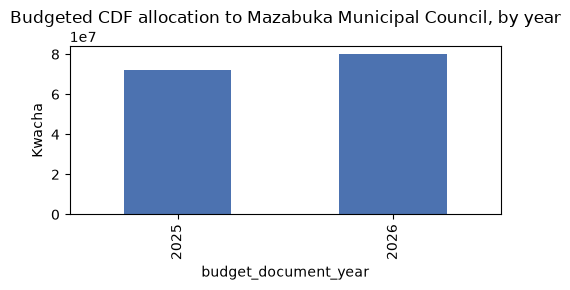

In [5]:
import matplotlib.pyplot as plt

cdf_grant = budget_revenue[
    (budget_revenue["category_name"] == "National Support (Grants)")
    & (budget_revenue["item_description"].str.contains("Constituency Development Fund", case=False, na=False))
    & (budget_revenue["period_year"] == budget_revenue["budget_document_year"])
]
ax = cdf_grant.set_index("budget_document_year")["amount_kwacha"].plot(kind="bar", figsize=(5, 3), color="#4C72B0")
ax.set_ylabel("Kwacha")
ax.set_title("Budgeted CDF allocation to Mazabuka Municipal Council, by year")
plt.tight_layout()
plt.show()


## 4. CDF Extraction (native + OCR)

CDF project lists and beneficiary lists are far messier than the budgets: council staff
scan and upload them as photographed tables. `src/extract_cdf.py` classifies every relevant
file as either `native` (clean extractable text — mostly the newest 2025/2026 documents) or
`ocr` (scanned image, or a corrupted-font 2024 document), based on the manual audit in
Section 2 plus a manual spot-check of actual text quality (page-count/size alone is not a
reliable signal — several "has a text layer" PDFs still turned out to be ligature garbage).

For OCR documents, `src/ocr_utils.py` renders each page with `pypdfium2` (pure Python, no
Poppler dependency) and runs **EasyOCR** (chosen because the Tesseract engine needs an
admin-level system install that wasn't available in this environment; EasyOCR installs via
pip only). Detected words are clustered into rows by vertical position and read left to
right, approximating the original table layout.

**On data structure — an honest limitation:** these lists use inconsistent column layouts
across documents (Ward/Zone/Type of Venture in some, Sex/Constituency/Ward in others, NRC
numbers in others). Rather than force an unreliable, silently-wrong column split from noisy
OCR text, every record is kept as **one serial-numbered row of free text**
(`sn` + `record_text`), grouped by document metadata (`year`, `constituency`, `category`).
This is a deliberate, documented trade-off: the data is fully usable for counting, filtering
by year/constituency/category, and text search, but further column-splitting (e.g. isolating
a `ward` field) would need manual review or a reference ward list to do reliably — noted as
future work in the Data in Brief paper.


In [6]:
import extract_cdf

out_projects = INTERIM_DIR / "cdf_projects.csv"
if not out_projects.exists():
    extract_cdf.main()

cdf_projects = pd.read_csv(INTERIM_DIR / "cdf_projects.csv")
cdf_beneficiaries = pd.read_csv(INTERIM_DIR / "cdf_beneficiaries.csv")
cdf_notices = pd.read_csv(INTERIM_DIR / "cdf_notices.csv")
ocr_rows = pd.read_csv(INTERIM_DIR / "ocr_raw_rows.csv")

print(f"CDF project records: {len(cdf_projects)}")
print(f"CDF beneficiary records: {len(cdf_beneficiaries)}")
print(f"CDF notice records: {len(cdf_notices)}")
print(f"Raw OCR rows captured (audit trail): {len(ocr_rows)}")
cdf_projects.head()


CDF project records: 300
CDF beneficiary records: 1503
CDF notice records: 5
Raw OCR rows captured (audit trail): 3752


,source_file,year,constituency,category,sn,record_text,page,extraction_method
0,APPROVED-COMMUNITY-PROJECTS-2025-MAGOYE1.pdf,2025,Magoye,approved,1,PROCUREMENT OF DESKS ALL EDUCATION,0,native
1,APPROVED-COMMUNITY-PROJECTS-2025-MAGOYE1.pdf,2025,Magoye,approved,2,FUEL FOR FEEDER ROADS ALL ROADS CONSTRUCT OF 1X3 CLASSROOM BLOCK AT NGWEZI PRIMARY SCHOOL,0,native
2,APPROVED-COMMUNITY-PROJECTS-2025-MAGOYE1.pdf,2025,Magoye,approved,3,"WITH WATER RETICULATION SYSTEM CHIVUNA EDUCATION CONSTRUCTION OF 1X3 CLASSROOM BLOCK ,1 STAFF HOUSE AND ABLUTION BLO...",0,native
3,APPROVED-COMMUNITY-PROJECTS-2025-MAGOYE1.pdf,2025,Magoye,approved,4,SCHOOL ITEBE EDUCATION,0,native
4,APPROVED-COMMUNITY-PROJECTS-2025-MAGOYE1.pdf,2025,Magoye,approved,5,CONSTRUCTION OF A 1X2 CRB AT MANYANA PRIMARY SCHOOL. KALAMA EDUCATION,0,native


In [7]:
print("Projects by year / constituency / status:")
cdf_projects.groupby(["year", "constituency", "category"]).size().unstack(fill_value=0)


Projects by year / constituency / status:


category               approved  proposed  status_update  unapproved
year constituency                                                   
2024 Magoye                  15         0              0           0
     Mazabuka Central         4         0              5           0
2025 Magoye                  11       117              0           4
     Mazabuka Central        61         0              0          45
2026 Mazabuka Central         0         0              0          38

In [8]:
print("Beneficiary records by CDF programme type:")
cdf_beneficiaries.groupby(["year", "category"]).size().unstack(fill_value=0)


Beneficiary records by CDF programme type:


category,empowerment_loan,secondary_school_bursary,skills_development_bursary,youth_women_community_grant
year,,,,
2024,37,632,31,18
2026,8,548,93,136


## 5. Document Catalog

The remaining ~80 documents on the site (Integrated Development Plan, council minutes,
audit reports, financial statements, legal Acts, stakeholder engagement plans, public
notices, etc.) were not all deep-parsed into their own line-item tables — several are long
narrative or scanned financial documents where full structured extraction was out of scope
for a one-week mini-project. Instead, `src/build_document_catalog.py` builds a full metadata
catalog (category, year, constituency where applicable, title, source URL, page count, file
size, text-layer status) so every source remains traceable and citable, satisfying the
"council administrative data... public council resolutions/reports" requirement even where
full tabulation wasn't attempted.


In [9]:
import build_document_catalog

out_catalog = INTERIM_DIR / "document_catalog.csv"
if not out_catalog.exists():
    build_document_catalog.main()

catalog = pd.read_csv(INTERIM_DIR / "document_catalog.csv")
print(f"Documents catalogued: {len(catalog)}")
catalog["category"].value_counts()


Documents catalogued: 100


category
council_minutes                      14
legal_act_reference                  11
cdf_project_list                     10
cdf_bursary_beneficiary_list          9
budget_consultative_meeting           7
cdf_grant_loan_beneficiary_list       7
financial_statement                   5
audit_report                          4
other                                 3
bi_annual_performance_report          3
community_engagement_minutes          3
approved_annual_budget                3
public_notice                         3
cdf_application_form_template         3
cdf_policy_guideline                  2
cdf_project_status_update             2
stakeholder_engagement_plan           2
investment_profile                    2
newsletter                            2
debt_arrears_monitoring               1
integrated_development_plan           1
national_policy_reference             1
ward_development_committee_notice     1
valuation_roll_notice                 1
Name: count, dtype: int64

## 6. Cleaning & Finalisation

`src/finalize_datasets.py` applies final cleaning (type coercion, deduplication, sorting)
and exports every dataset to the assignment's required format: **CSV, pipe (`|`) separated**,
named `db-unza26-csc4792-[description].csv`.

**Another bug worth recording:** `pandas.read_csv` auto-infers numeric-looking columns, which
silently stripped the leading zeros off the budget `category_code`/`item_code` fields
(`"01"` -> `1`, `"001"` -> `1`) — corrupting the council's own chart-of-accounts codes. Fixed
by reading those columns with an explicit `dtype=str`. A reminder that "looks numeric" and
"is an identifier" are different things.


In [10]:
import finalize_datasets

finalize_datasets.main()


db-unza26-csc4792-mazabuka_council_budget_revenue_items.csv: 675 rows, 8 columns
db-unza26-csc4792-mazabuka_council_budget_economic_classification.csv: 12 rows, 6 columns
db-unza26-csc4792-mazabuka_council_document_catalog.csv: 100 rows, 10 columns
db-unza26-csc4792-mazabuka_cdf_projects.csv: 300 rows, 8 columns
db-unza26-csc4792-mazabuka_cdf_beneficiaries.csv: 1503 rows, 8 columns
db-unza26-csc4792-mazabuka_cdf_notices.csv: 5 rows, 8 columns


In [11]:
final_files = sorted(DATASET_DIR.glob("db-unza26-csc4792-*.csv"))
summary = []
for f in final_files:
    df = pd.read_csv(f, sep="|")
    summary.append({"file": f.name, "rows": len(df), "columns": len(df.columns)})
pd.DataFrame(summary)


,file,rows,columns
0,db-unza26-csc4792-mazabuka_cdf_beneficiaries.csv,1503,8
1,db-unza26-csc4792-mazabuka_cdf_notices.csv,5,8
2,db-unza26-csc4792-mazabuka_cdf_projects.csv,300,8
3,db-unza26-csc4792-mazabuka_council_budget_economic_classification.csv,12,6
4,db-unza26-csc4792-mazabuka_council_budget_revenue_items.csv,675,8
5,db-unza26-csc4792-mazabuka_council_document_catalog.csv,100,10


## 7. Limitations & Reuse Potential

**Limitations:**
- CDF project/beneficiary records are kept as free-text entries per record rather than fully
  split into individual fields (ward, sector, amount), due to inconsistent source layouts and
  OCR noise (see Section 4). `record_text` retains everything for downstream re-parsing.
- Older (2020-2023) financial statements and some audit reports are scanned, multi-page
  financial tables; these are catalogued (Section 5) but not fully tabulated — only the
  native-text 2024 financial statements and select audit reports were parsed in depth.
- OCR output (~16 documents, ~80 pages) was not manually verified line-by-line; `ocr_raw_rows.csv`
  is retained as a full audit trail so any record can be checked against its source image.
- The 2026 "Economic Classification" summary table was reliably parseable for the 2025 budget
  document only, due to inconsistent page layout across years; the richer revenue line-item
  table (675 rows, all 3 years) is the primary budget dataset.

**Reuse potential:** this dataset supports research and civic-tech applications on local
government transparency and fiscal decentralisation in Zambia — e.g. tracking CDF utilisation
against the Local Government (Amendment) Act 2023/2026 reforms, comparing locally generated
revenue composition across councils, or auditing budget-to-project-delivery ratios.

## References

- Republic of Zambia. (n.d.). *Ministry of Local Government and Rural Development.* https://www.mlgrd.gov.zm
- *Local Government Act, 2019.* https://zambialii.org/akn/zm/act/2019/2/eng@2019-04-11
- *Local Government (Amendment) Act, 2023.* https://zambialii.org/akn/zm/act/2023/28/eng@2023-12-26
- *Local Government (Amendment) Act, 2026.* https://zambialii.org/akn/zm/act/2026/76/eng@2026-06-12
- Phiri, L. (2026). *A Multi-Source Dataset for CS1 Failure Prediction* [Dataset]. https://www.kaggle.com/datasets/lightonphiri/a-multisource-dataset-for-cs1-failure-prediction
- Mazabuka Municipal Council. https://www.mazabukacouncil.gov.zm
